In [1]:
# 와인 예제
# 데이터 생성
from sklearn.datasets import load_wine

wine = load_wine()

In [2]:
# 와인 정보를 이용하여 모델에 학습을 시키고 성능을 확인하세요.
# 단, 시각화를 위해 alcohol과 ash만 독립 변수로 활용
import pandas as pd
# 독립, 종속 분리
X = pd.DataFrame(wine.data, columns=wine.feature_names)
X = X[['alcohol','ash']]
y = wine.target

In [3]:
# 훈련, 테스트 분리
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [4]:
# 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# 학습
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, max_depth=3)
model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
# 성능이 생각보다 좋지 않음 => 원래 독립변수가 13개인데 그중 2개만 가져와서 학습했기 때문에
print(f'성능 : {model.score(X_test_scaled, y_test)}')

성능 : 0.7777777777777778


In [7]:
# 시각화 범위 설정 (스케일링 된 데이터 기준)
# -0.5, +0.5는 그래프 여백
import numpy as np
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
hh = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, hh),
                     np.arange(y_min, y_max, hh))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)



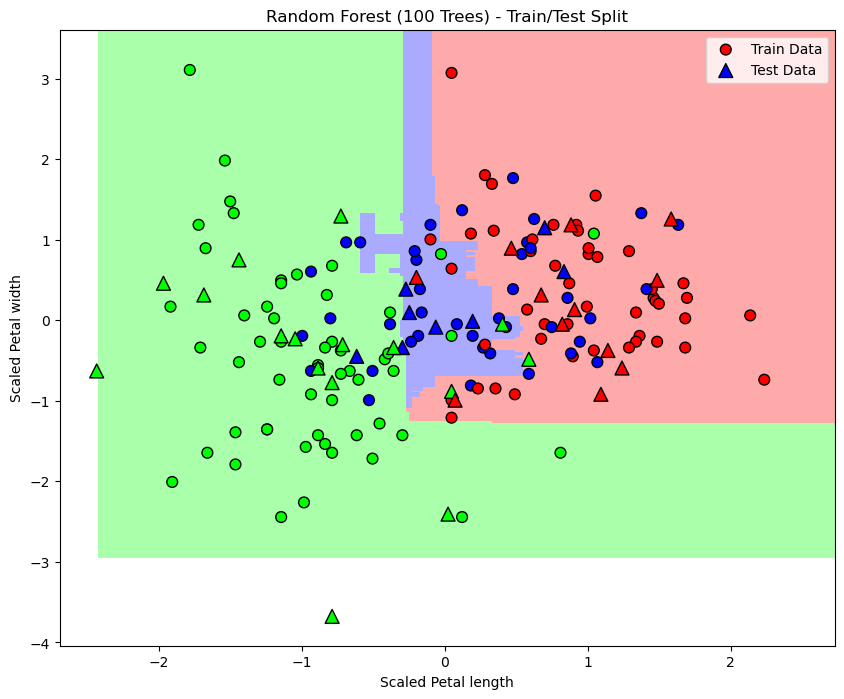

In [8]:

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.figure(figsize=(10, 8))
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# 훈련 데이터 (동그라미)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, 
            cmap=cmap_bold, edgecolor='k', s=60, label='Train Data')

# 테스트 데이터 (삼각형)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, 
            cmap=cmap_bold, marker='^', edgecolor='k', s=100, label='Test Data')

plt.xlabel('Scaled Petal length')
plt.ylabel('Scaled Petal width')
plt.title('Random Forest (100 Trees) - Train/Test Split')
plt.legend()
plt.show()